In [1]:
"""Hero-Chart 1 (H1): Profile der Top-Ressorts 2024.

Zentrale Aussage: Sechs Ressorts dominieren den Digitalhaushalt, jedes mit
einem fundamental anderen Profil. Verwaltungs-IT - der einzig sinnvoll in
einem BMDS buendelbare Bereich - ist nur ein Teil davon.

Output: figures/h1_ressort_profile_2024.png + .pdf
"""
import sys
from pathlib import Path
sys.path.insert(0, '..')  # repo root, relativ zum notebooks/-Verzeichnis

In [2]:
import matplotlib.pyplot as plt
from src import FIGURES_DIR
from src.load import load, kategorien_allokation
from src.style import apply_style, COLORS, KATEGORIE_FARBEN, RESSORT_KURZ, add_quelle

In [3]:
apply_style()
df = load()  # nutzt Repo-Root-Default aus src.load

In [4]:
# Daten
alloc = kategorien_allokation(df, jahr=2024)
profile = alloc.pivot_table(index='einzelplan', columns='kategorie', values='volumen', fill_value=0)
profile = profile / 1e6  # Mrd.
profile['Sigma'] = profile.sum(axis=1)
top7 = profile.sort_values('Sigma', ascending=False).head(7)

In [5]:
# Reihenfolge der Kategorien: Verwaltung zuletzt, damit visuell hervorstechend
kat_order = ['Bundeswehr', 'Infrastruktur', 'Forschung', 'Kompetenzen',
             'Wirtschaft', 'Kultur', 'Gesundheit', 'Unteilbar', 'Verwaltung']
kat_order = [k for k in kat_order if k in top7.columns]

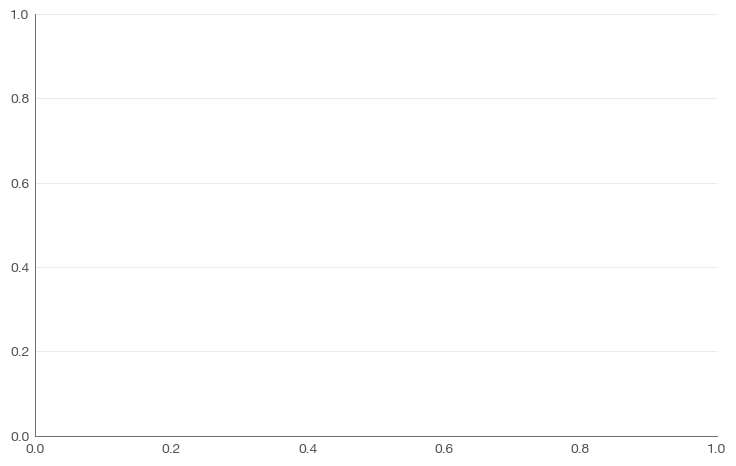

In [6]:
# Plot
fig, ax = plt.subplots(figsize=(11, 6.8))
fig.subplots_adjust(left=0.16, right=0.78, top=0.80, bottom=0.18)

In [7]:
ressorts = top7.index.tolist()
y_pos = range(len(ressorts))
labels = [f"{RESSORT_KURZ.get(int(ep), f'EP{int(ep)}')}\n{top7.loc[ep,'Sigma']:.2f} Mrd €"
          for ep in ressorts]

In [8]:
left = [0.0] * len(ressorts)
bar_handles = {}
for kat in kat_order:
    werte = (top7[kat] / top7['Sigma'] * 100).values
    h = ax.barh(y_pos, werte, left=left, height=0.72,
                color=KATEGORIE_FARBEN[kat], edgecolor='white', linewidth=1.4,
                label=kat)
    bar_handles[kat] = h
    # Direkte Beschriftung der dominanten Segmente (>= 15%)
    for i, w in enumerate(werte):
        if w >= 15:
            x_text = left[i] + w/2
            ax.text(x_text, i, f"{kat}\n{w:.0f}%",
                    ha='center', va='center',
                    fontsize=9, color='white', weight='medium')
    left = [l + w for l, w in zip(left, werte)]

In [9]:
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.set_xlabel('Anteil am Digital-Soll des Ressorts')
ax.grid(axis='x', linewidth=0.6, color=COLORS['grid'])
ax.set_axisbelow(True)

In [10]:
# Titel und Kernaussage
fig.text(0.02, 0.95,
         'Sechs Ressorts, sechs fundamental verschiedene Digital-Profile',
         fontsize=15, weight='medium', color=COLORS['text'])
fig.text(0.02, 0.91,
         'Aufgabenprofile der Top-7-Bundesressorts im Digitalhaushalt 2024, anteilig auf 9 ZEW-Kategorien',
         fontsize=10, color=COLORS['text_secondary'])

Text(0.02, 0.91, 'Aufgabenprofile der Top-7-Bundesressorts im Digitalhaushalt 2024, anteilig auf 9 ZEW-Kategorien')

In [11]:
# Annotation rechts: BMDS-Reichweite
ax.axvspan(0, 0, alpha=0)  # Platzhalter
fig.text(0.80, 0.79,
         'Nur die grüne Verwaltungs-IT',
         fontsize=10, color=COLORS['text'], weight='medium')
fig.text(0.80, 0.75,
         'ließe sich realistisch in\neinem BMDS bündeln:',
         fontsize=10, color=COLORS['text_secondary'])
fig.text(0.80, 0.66,
         '21–23 %',
         fontsize=24, color=KATEGORIE_FARBEN['Verwaltung'], weight='bold')
fig.text(0.80, 0.62,
         'des Digital-Solls 2024',
         fontsize=9, color=COLORS['text_secondary'])
fig.text(0.80, 0.55,
         '(3,7 – 4,1 Mrd €)',
         fontsize=9, color=COLORS['text_tertiary'])

Text(0.8, 0.55, '(3,7 – 4,1 Mrd €)')

In [12]:
# Legende unten fuer kleine Segmente
from matplotlib.patches import Patch
small_kats = [k for k in kat_order if k not in ['Verwaltung','Bundeswehr','Infrastruktur','Forschung','Kompetenzen','Wirtschaft']]
if small_kats:
    handles = [Patch(facecolor=KATEGORIE_FARBEN[k], label=k) for k in small_kats]
    fig.legend(handles=handles, loc='lower center', ncol=len(small_kats),
               bbox_to_anchor=(0.5, 0.07), frameon=False, fontsize=9)

In [13]:
add_quelle(ax, 'Quelle: Digitalhaushalt Open Data (ZEW/Agora), enge Abgrenzung. Anteilige Allokation bei Mehrfach-Kategorien.')

In [14]:
# Speichern
out_dir = FIGURES_DIR
fig.savefig(out_dir / 'h1_ressort_profile_2024.png', dpi=200)
fig.savefig(out_dir / 'h1_ressort_profile_2024.pdf')
print(f"Gespeichert: {out_dir/'h1_ressort_profile_2024.png'}")
print(f"Gespeichert: {out_dir/'h1_ressort_profile_2024.pdf'}")

Gespeichert: /Users/moe/Documents/GitHub/agora_challenge/figures/h1_ressort_profile_2024.png
Gespeichert: /Users/moe/Documents/GitHub/agora_challenge/figures/h1_ressort_profile_2024.pdf
